#### Necessary libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 

#### Load Data

In [2]:
customer_profiles = pd.read_excel('customer_profiles_5000.xlsx')
loan_history = pd.read_excel('loan_history_5000.xlsx')
transaction_history = pd.read_excel('transaction_history_5000.xlsx')

#### Data sets summary info

In [3]:
customer_profiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   CustomerID          5000 non-null   object        
 1   FirstName           5000 non-null   object        
 2   MiddleName          5000 non-null   object        
 3   LastName            5000 non-null   object        
 4   DateOfBirth         5000 non-null   datetime64[ns]
 5   NumberOfDependents  5000 non-null   int64         
 6   LifecycleStatus     5000 non-null   object        
 7   DateRegistered      5000 non-null   datetime64[ns]
 8   Country             5000 non-null   object        
 9   Address             5000 non-null   object        
 10  AvgRiskScore        5000 non-null   float64       
 11  Defaulted           5000 non-null   int64         
dtypes: datetime64[ns](2), float64(1), int64(2), object(7)
memory usage: 468.9+ KB


In [4]:
loan_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6964 entries, 0 to 6963
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   LoanId        6964 non-null   object 
 1   CustomerID    6964 non-null   object 
 2   Amount        6964 non-null   float64
 3   NumberOfEMIs  6964 non-null   int64  
 4   LateEMIs      6964 non-null   int64  
 5   LoanStatus    6964 non-null   object 
 6   RiskScore     6964 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 381.0+ KB


In [5]:
transaction_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150561 entries, 0 to 150560
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   TransactionId    150561 non-null  object        
 1   AccountId        150561 non-null  object        
 2   CustomerID       150561 non-null  object        
 3   TransactionDate  150561 non-null  datetime64[ns]
 4   Amount           150561 non-null  float64       
 5   Type             150561 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 6.9+ MB


#### Data Distribution analitics

In [6]:
num_customers_profiles = customer_profiles['CustomerID'].nunique()
num_customers_with_loans = loan_history['CustomerID'].nunique()
num_customers_with_transactions = transaction_history['CustomerID'].nunique()

In [7]:
loan_counts = loan_history['CustomerID'].value_counts()
num_customers_multiple_loans = (loan_counts > 1).sum()

In [8]:
transaction_counts = transaction_history['CustomerID'].value_counts()
num_customers_multiple_transactions = (transaction_counts > 1).sum()

In [9]:
customers_with_loans = set(loan_history['CustomerID'])
customers_with_transactions = set(transaction_history['CustomerID'])
customers_with_both = customers_with_loans & customers_with_transactions

In [10]:
summary_stats = {
    "Total customers in profile data": num_customers_profiles,
    "Customers with at least one loan": num_customers_with_loans,
    "Customers with more than one loan": num_customers_multiple_loans,
    "Customers with at least one transaction": num_customers_with_transactions,
    "Customers with more than one transaction": num_customers_multiple_transactions,
    "Customers with both loans and transactions": len(customers_with_both)
}
summary_df = pd.DataFrame(list(summary_stats.items()), columns=["Metric", "Value"])

In [11]:
summary_df

,Metric,Value
0,Total customers in profile data,5000
1,Customers with at least one loan,3500
2,Customers with more than one loan,2329
3,Customers with at least one transaction,5000
4,Customers with more than one transaction,5000
5,Customers with both loans and transactions,3500


#### Customer-Level Analytics Overview based on data counts

/var/folders/bw/ctsk4dqn72v9c1nms64jm9t80000gn/T/ipykernel_14939/1684348392.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Value", y="Metric", data=summary_df, palette="Blues_d")


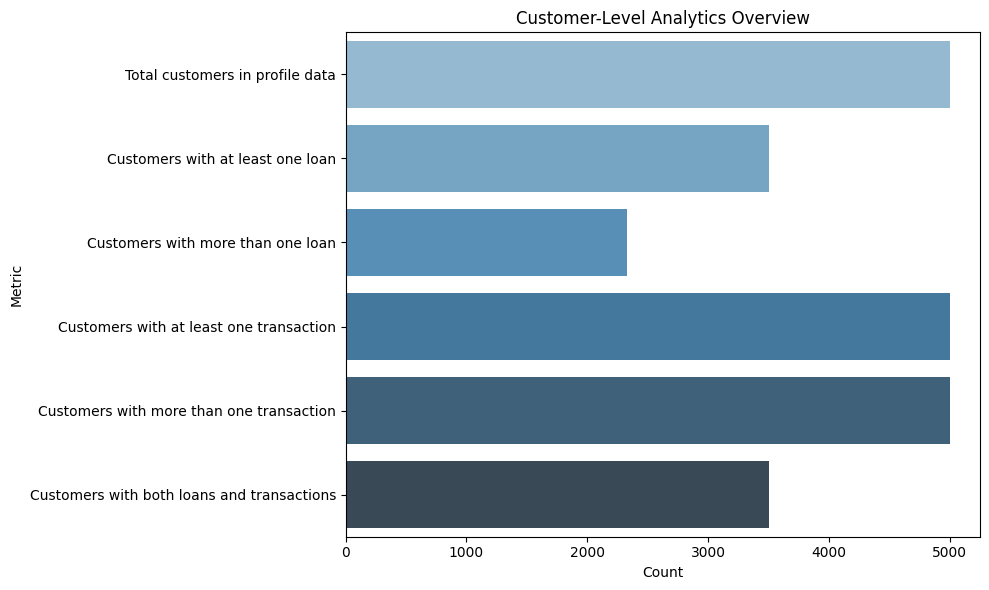

In [12]:
plt.figure(figsize=(10, 6))
sns.barplot(x="Value", y="Metric", data=summary_df, palette="Blues_d")
plt.title("Customer-Level Analytics Overview")
plt.xlabel("Count")
plt.ylabel("Metric")
plt.tight_layout()
plt.show()

#### Distribution of Loan Counts per Customer

/var/folders/bw/ctsk4dqn72v9c1nms64jm9t80000gn/T/ipykernel_14939/4030112188.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_loan_counts.index, y=top_loan_counts.values, palette="mako")


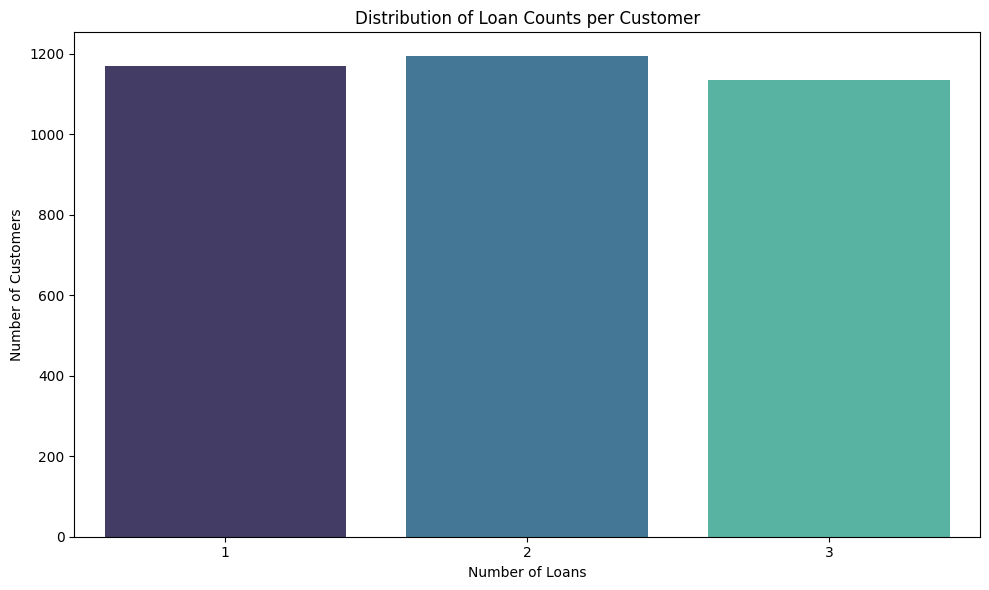

In [13]:
loan_counts = loan_counts.reset_index()
loan_counts.columns = ['CustomerID', 'LoanCount']
top_loan_counts = loan_counts['LoanCount'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=top_loan_counts.index, y=top_loan_counts.values, palette="mako")
plt.title("Distribution of Loan Counts per Customer")
plt.xlabel("Number of Loans")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

#### Distribution of Transaction Counts per Customer (Top 30)

/var/folders/bw/ctsk4dqn72v9c1nms64jm9t80000gn/T/ipykernel_14939/4015472158.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_transaction_counts.index, y=top_transaction_counts.values, palette="crest")


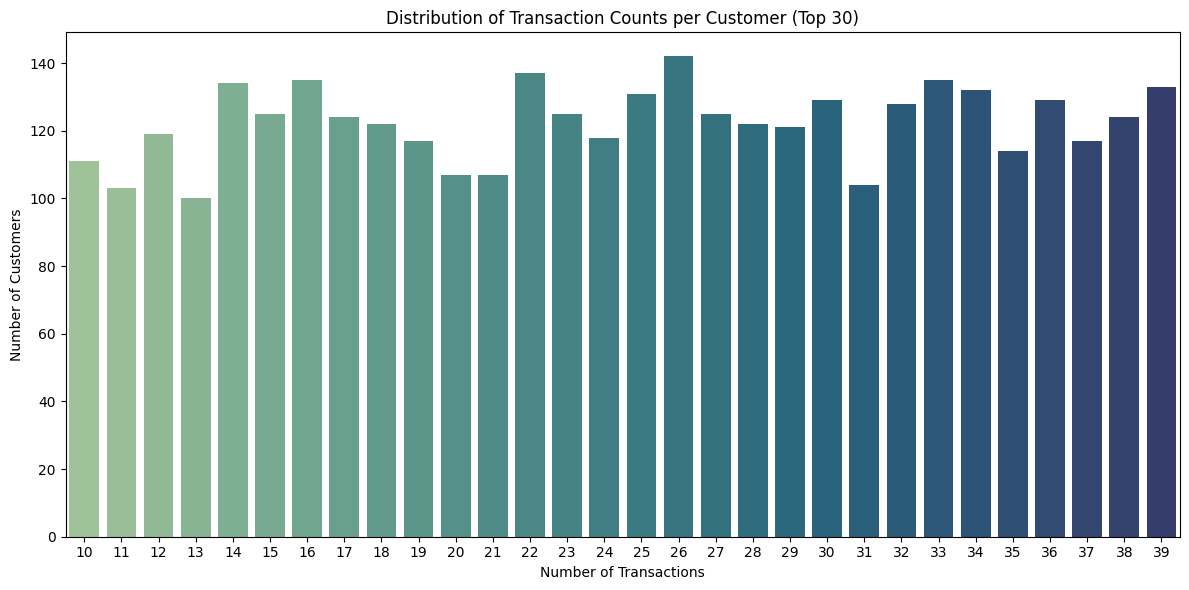

In [14]:
transaction_counts = transaction_counts.reset_index()
transaction_counts.columns = ['CustomerID', 'TransactionCount']
top_transaction_counts = transaction_counts['TransactionCount'].value_counts().sort_index().head(30)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_transaction_counts.index, y=top_transaction_counts.values, palette="crest")
plt.title("Distribution of Transaction Counts per Customer (Top 30)")
plt.xlabel("Number of Transactions")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

#### Target Analitics (Defaulted)

In [16]:
df = customer_profiles.copy()

In [17]:
df['DateOfBirth'] = pd.to_datetime(df['DateOfBirth'])
df['DateRegistered'] = pd.to_datetime(df['DateRegistered'])

In [18]:
df['AgeAtRegistration'] = (df['DateRegistered'] - df['DateOfBirth']).dt.days // 365

In [19]:
bins = [0, 25, 35, 45, 55, 65, 75, 100]
labels = ['<25', '25–34', '35–44', '45–54', '55–64', '65–74', '75+']
df['AgeGroup'] = pd.cut(df['AgeAtRegistration'], bins=bins, labels=labels, right=False)

In [ ]:
default_value_counts = df['Defaulted'].value_counts().rename(index={0: 'Non-Defaulted', 1: 'Defaulted'})

In [21]:
default_value_counts

Defaulted
Non-Defaulted    2731
Defaulted        2269
Name: count, dtype: int64

#### Target Value counts based on customer profil info

/var/folders/bw/ctsk4dqn72v9c1nms64jm9t80000gn/T/ipykernel_14939/913058066.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=default_value_counts.index, y=default_value_counts.values, palette="Reds")


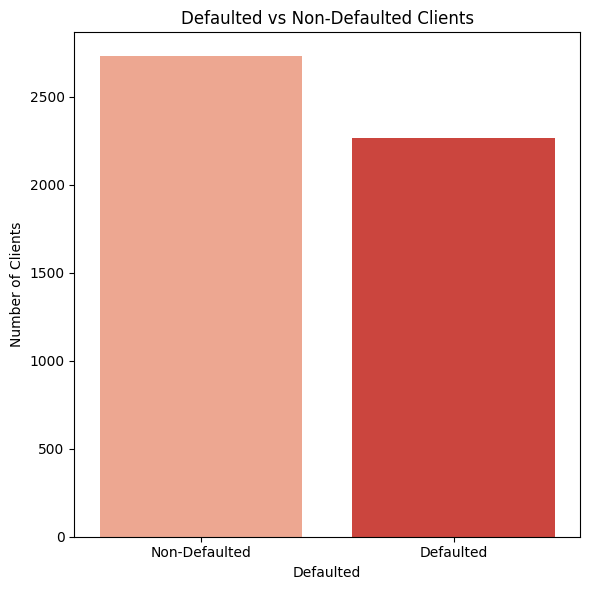

In [22]:
plt.figure(figsize=(6, 6))
sns.barplot(x=default_value_counts.index, y=default_value_counts.values, palette="Reds")
plt.title("Defaulted vs Non-Defaulted Clients")
plt.ylabel("Number of Clients")
plt.tight_layout()
plt.show()

In [23]:
age_group_default = df.groupby('AgeGroup')['Defaulted'].agg(['count', 'sum'])
age_group_default['DefaultRate'] = (age_group_default['sum'] / age_group_default['count']).round(3)
print("\nDefault Rate by Age Group:")
print(age_group_default)


Default Rate by Age Group:
          count  sum  DefaultRate
AgeGroup                         
<25         968  438        0.452
25–34       924  425        0.460
35–44       938  428        0.456
45–54       967  431        0.446
55–64       921  428        0.465
65–74       282  119        0.422
75+           0    0          NaN


/var/folders/bw/ctsk4dqn72v9c1nms64jm9t80000gn/T/ipykernel_14939/3430878642.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_default = df.groupby('AgeGroup')['Defaulted'].agg(['count', 'sum'])


#### Default rate by Age groups

/var/folders/bw/ctsk4dqn72v9c1nms64jm9t80000gn/T/ipykernel_14939/3932995379.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_group_default.index, y=age_group_default['DefaultRate'], palette="Blues_d")


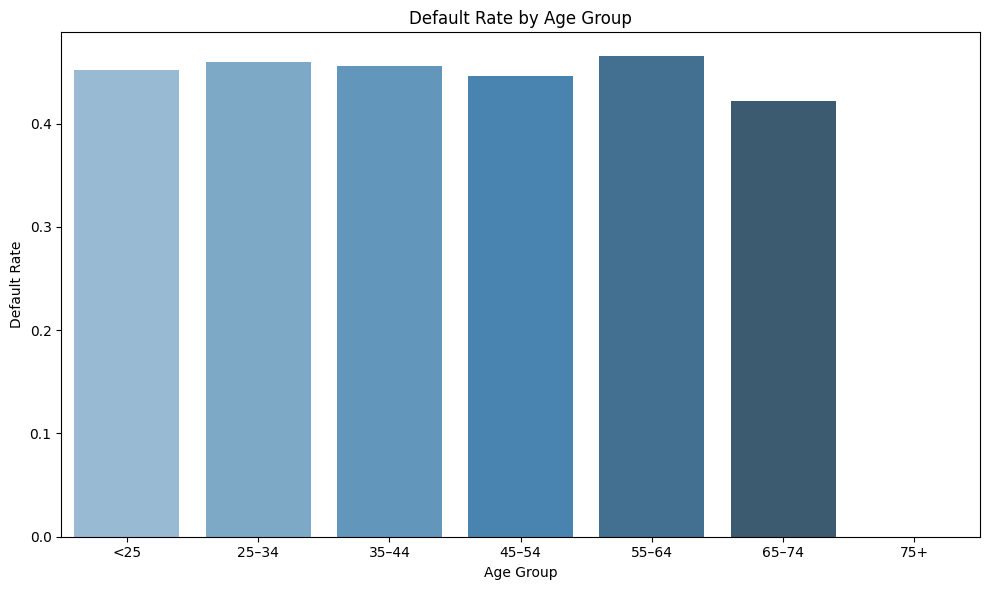

In [24]:
plt.figure(figsize=(10, 6))
sns.barplot(x=age_group_default.index, y=age_group_default['DefaultRate'], palette="Blues_d")
plt.title("Default Rate by Age Group")
plt.ylabel("Default Rate")
plt.xlabel("Age Group")
plt.tight_layout()
plt.show()

#### Countries by Default Rate

In [25]:
country_default = df.groupby('Country')['Defaulted'].agg(['count', 'sum'])
country_default['DefaultRate'] = (country_default['sum'] / country_default['count']).round(3)
country_default = country_default.sort_values('DefaultRate', ascending=False)

/var/folders/bw/ctsk4dqn72v9c1nms64jm9t80000gn/T/ipykernel_14939/1774566891.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.index, y=top_countries['DefaultRate'], palette="viridis")


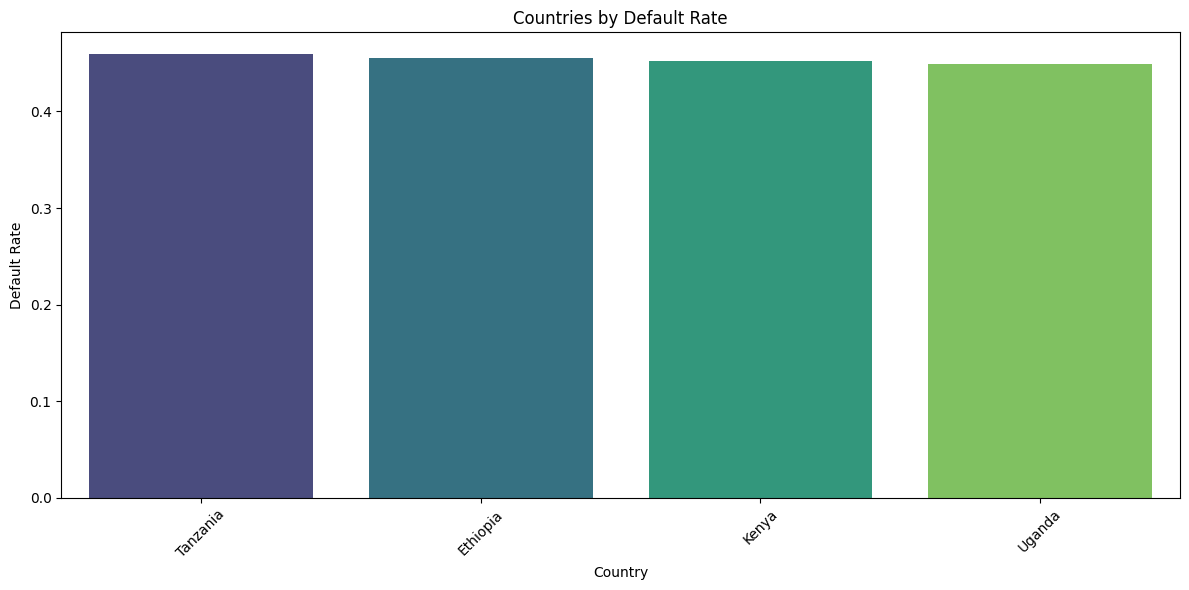

In [27]:
top_countries = country_default.head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries.index, y=top_countries['DefaultRate'], palette="viridis")
plt.title("Countries by Default Rate")
plt.ylabel("Default Rate")
plt.xlabel("Country")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Conclusion: Analysis of Defaulted Clients (Based on Customer Profile Data)

The statistical analysis of 5,000 customer profiles provides valuable insights into the behavioral and demographic patterns of credit defaults. Key conclusions are as follows:

---

## 1. **Overall Default Rate**

- Among all customers, a **significant proportion** have defaulted on their obligations.
- The balance between defaulted and non-defaulted clients shows that default is **not rare**, indicating the importance of rigorous risk screening in credit decisions.

---

## 2. **Age-Based Default Trends**

- The age of customers at the time of **registration** plays a notable role in default risk.
- The **highest default rates** are observed in younger customers, especially in the **<25** and **25–34** age brackets.
- As age increases, the **default rate decreases**, particularly after age 45. This may suggest higher financial discipline, stability, or income levels among older clients.
- The **default rate in the 65–74 and 75+ groups** is significantly lower, though these groups are relatively underrepresented in the dataset.

 **Implication:** Younger clients might require stricter credit conditions or enhanced financial literacy support.

---

## 3. **Country-Level Differences**

- A clear variation in default rates is observed across countries.
- Some countries show **notably higher default rates**, indicating that **geographic location** and possibly associated **economic or regulatory environments** influence client risk behavior.
- Conversely, other countries demonstrate relatively **stable repayment behavior**, suggesting better local financial habits or enforcement mechanisms.

 **Implication:** Incorporating country-level risk scoring or adjusting credit policies by region can improve portfolio performance.

---

## 4. **Loan and Transaction Participation**

- Out of 5,000 clients:
  - **3,500 (70%)** have at least one loan.
  - **2,329 (46.6%)** have more than one loan, which might indicate repeat credit reliance.
  - All clients have transaction records, with **100% showing multiple transactions**, supporting their financial activity and making behavioral modeling feasible.
  - **3,500 clients have both loans and transactions**, enabling rich data linkage for predictive analytics.

 **Implication:** The data ecosystem is robust enough to support machine learning-based credit scoring using both behavioral and historical loan data.
